In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")
print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


In [2]:
print("⏳ Cargando datos... (puede tardar un minuto)")
df = pd.read_csv('/content/sample_data/MetroPT3(AirCompressor).csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.set_index('timestamp', inplace=True)

# Eliminar la columna basura
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"✅ Datos cargados listos para analizar. Total registros: {len(df):,}")

⏳ Cargando datos... (puede tardar un minuto)
✅ Datos cargados listos para analizar. Total registros: 1,516,948


In [3]:
df_hourly = df.resample('1h').mean()

fallas = [
    {'inicio': '2020-04-18 00:00:00', 'fin': '2020-04-18 23:59:00', 'nombre': 'Falla 1: Fuga de aire Alto estrés'},
    {'inicio': '2020-05-29 23:30:00', 'fin': '2020-05-30 06:00:00', 'nombre': 'Falla 2: Fuga de aire Mantenimiento de alto estrés'},
    {'inicio': '2020-06-05 10:00:00', 'fin': '2020-06-07 14:30:00', 'nombre': 'Falla 3: Fuga de aire Mantenimiento de alto estrés'},
    {'inicio': '2020-07-15 14:30:00', 'fin': '2020-07-15 19:00:00', 'nombre': 'Falla 3: Fuga de aire Mantenimiento de alto estrés'}

]

print("✅ Datos agrupados por hora y zonas de fallas definidas en 2020.")

✅ Datos agrupados por hora y zonas de fallas definidas en 2020.


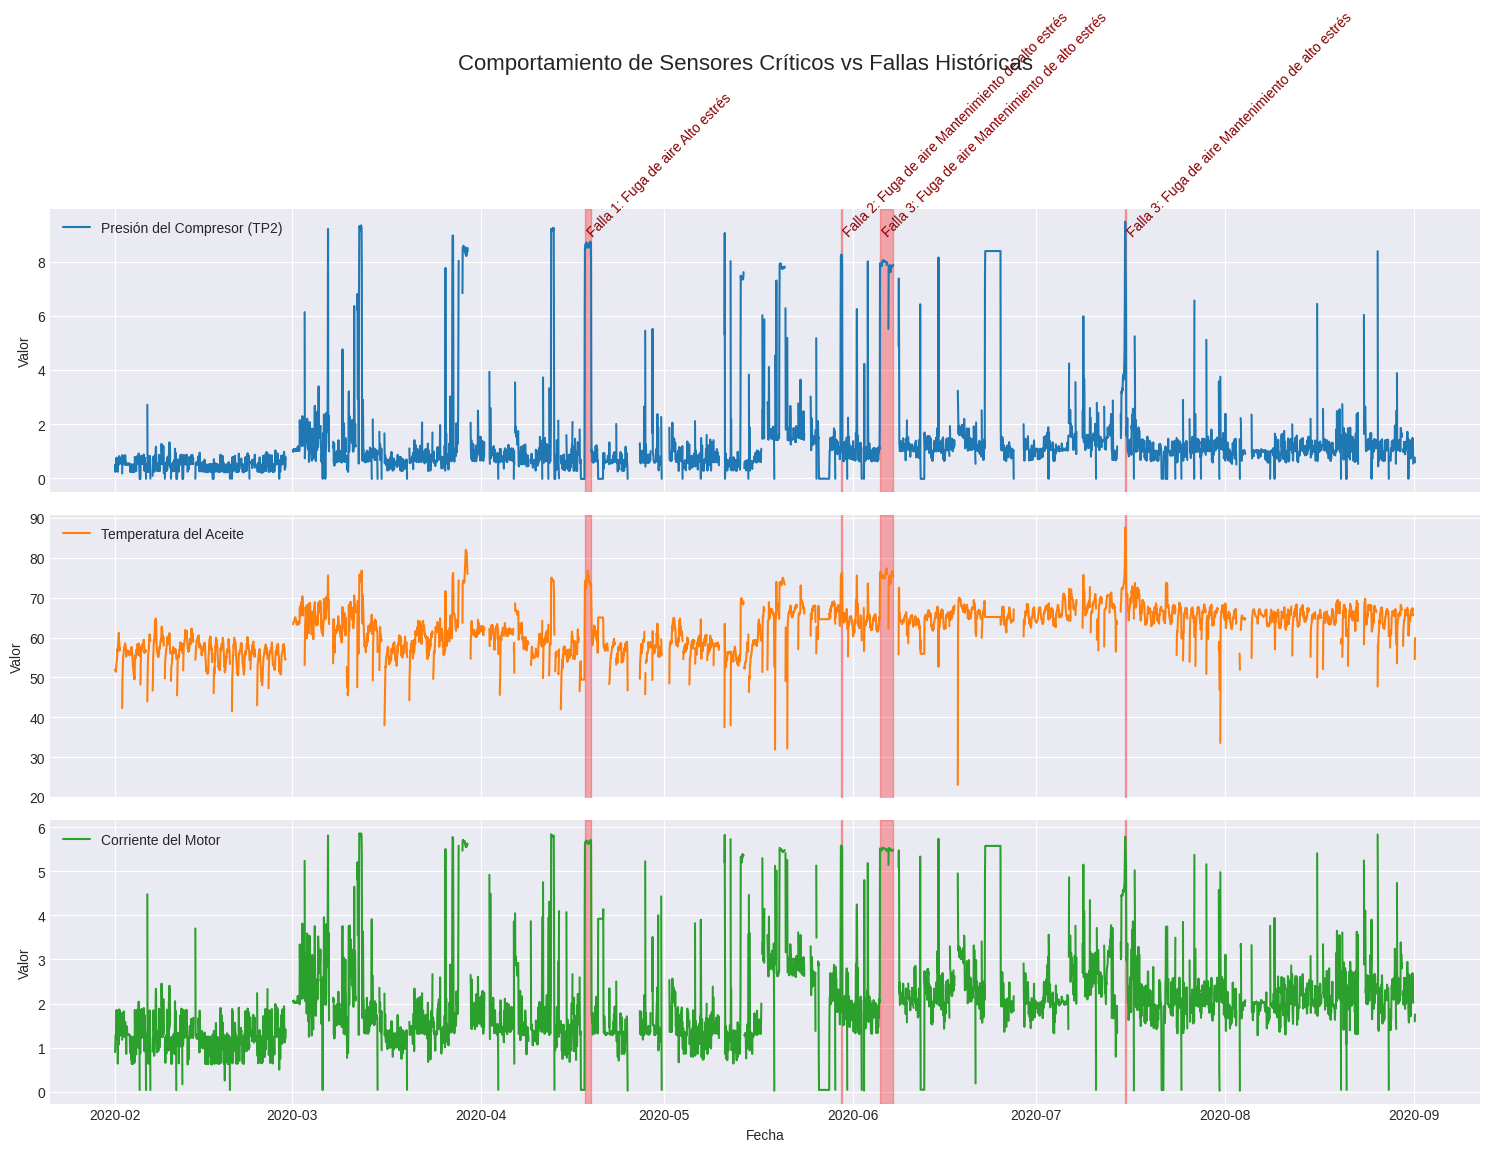

In [4]:
sensores_criticos = ['TP2', 'Oil_temperature', 'Motor_current']
nombres_espanol = ['Presión del Compresor (TP2)', 'Temperatura del Aceite', 'Corriente del Motor']

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Comportamiento de Sensores Críticos vs Fallas Históricas', fontsize=16, y=0.92)

for i, (sensor, nombre) in enumerate(zip(sensores_criticos, nombres_espanol)):
    axes[i].plot(df_hourly.index, df_hourly[sensor], label=nombre, color=sns.color_palette()[i])
    axes[i].set_ylabel('Valor')
    axes[i].legend(loc='upper left')


    for falla in fallas:
        axes[i].axvspan(pd.to_datetime(falla['inicio']), pd.to_datetime(falla['fin']),
                        color='red', alpha=0.3)
        if i == 0:
            axes[i].text(pd.to_datetime(falla['inicio']), axes[i].get_ylim()[1]*0.9,
                         falla['nombre'], color='darkred', rotation=45)

plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

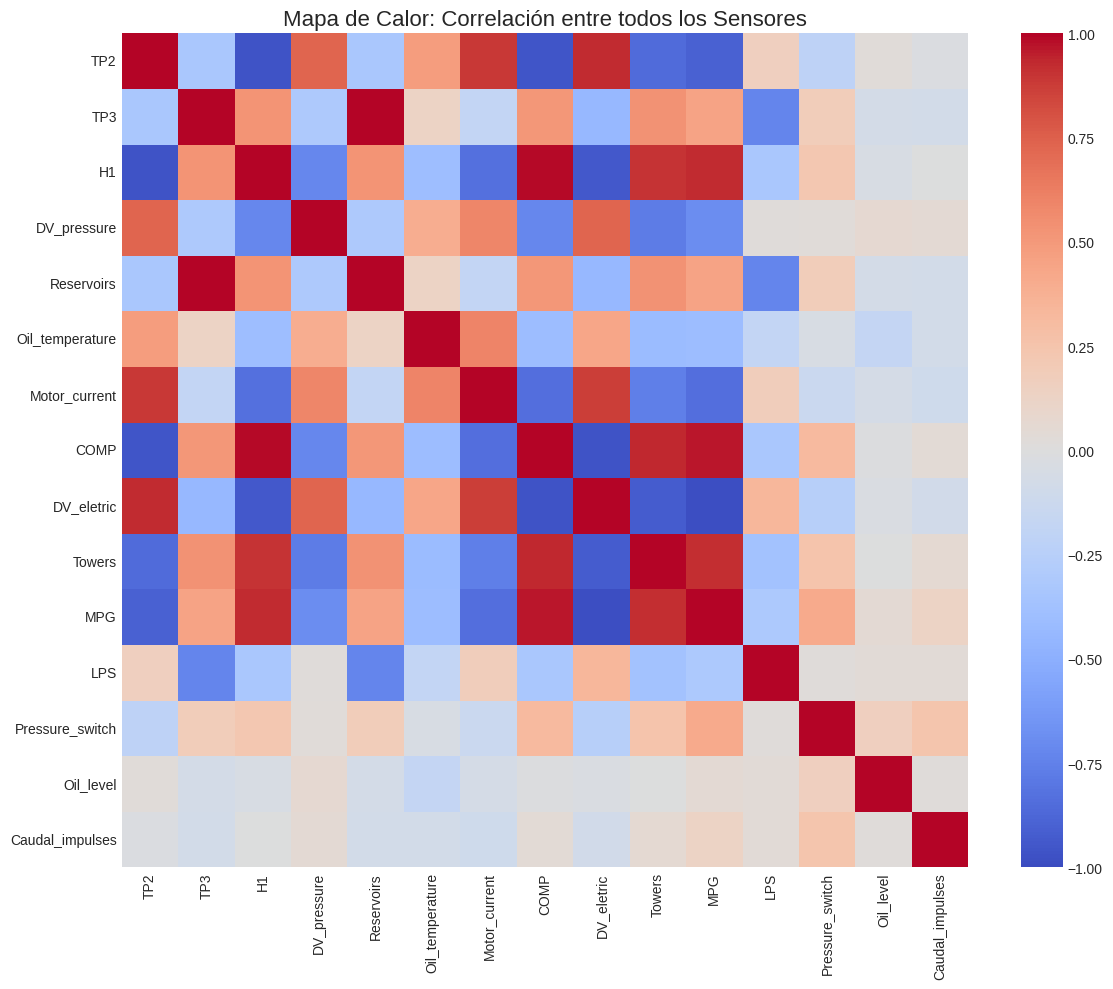

In [5]:
plt.figure(figsize=(12, 10))
correlacion = df_hourly.corr()

sns.heatmap(correlacion, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Mapa de Calor: Correlación entre todos los Sensores', fontsize=16)
plt.tight_layout()
plt.show()

# 📊 Análisis de Comportamiento Previo a las Fallas


Al observar la superposición de los datos históricos con las zonas críticas de falla (franjas rojas), podemos identificar patrones de comportamiento anómalo previo a cada evento:

1. **Inestabilidad en la Presión del Compresor (TP2):** En las semanas previas a la Falla 1 (abril 2020) se observa un aumento progresivo en la amplitud de los picos de presión, seguido de una estabilización abrupta durante la falla que rompe el patrón cíclico normal del compresor. Las Fallas 2 y 3 (junio 2020), que ocurren en un periodo muy cercano entre sí, muestran una zona de presión particularmente irregular con caídas sostenidas, consistente con una pérdida gradual de hermeticidad en el sistema de aire.

2. **Temperatura del Aceite como indicador de estrés térmico:** Las tres primeras fallas coinciden con periodos donde la temperatura del aceite presenta mayor variabilidad respecto a su comportamiento basal. Particularmente antes de la Falla 3 se observa una caída pronunciada de temperatura que podría indicar una pérdida de aceite o un cambio en las condiciones de operación del compresor previo al evento.

3. **Corriente del Motor como indicador de sobrecarga:** Durante los periodos de falla la corriente del motor muestra reducciones en su variabilidad normal, lo que sugiere que el compresor entra en un régimen de operación diferente — posiblemente ciclos más cortos o apagados frecuentes — como consecuencia de la pérdida de presión o aceite.

**Conclusión:** El análisis visual confirma que las fallas del sistema de compresor del MetroPT-3 no son eventos instantáneos sino procesos de degradación con señales medibles en los sensores con antelación, especialmente en TP2 y Oil_temperature. Sin embargo, la proximidad temporal entre las Fallas 2 y 3 (ambas en junio 2020) y la naturaleza gradual de la Falla 4 (julio 2020) representan los casos más desafiantes para los modelos predictivos, como fue confirmado posteriormente en el análisis de machine learning donde estas fallas mostraron los recalls más bajos.